# M0 P0-C-D1 full endpoint analysis

## tl;dr

- The returned archive is intact and contains exactly matched `true/fixed/shuffled` full outputs: 1,257 endpoints and 91 tracklets per mode.
- `true-fixed = +0.4375 Success / +0.5231 Precision`; both tracklet-bootstrap 95% intervals include zero and both are below the preregistered `+0.5 / +1.0` gate.
- `true-shuffled = -0.1233 Success / +0.0557 Precision`; correct physical-time alignment does not beat the shuffled negative control.
- The apparent `true-fixed` mean-error gain is long-tail driven: one already-failed tracklet contributes a 9.09 m tracklet-average gain and all 12 fallback reductions. Excluding it reduces the mean-error gain from 0.1910 m to 0.0397 m.
- Verdict: `NO_GO_P0C_A2_TRUE_DT_PROMOTION` is confirmed. M0-1 is complete, but M0 as a whole remains open because A/B/C four-protocol output, proposal oracle, and candidate audit are missing.


## Context & Methods

This notebook is the reproducible companion to the M0 P0-C-D1 technical report. The unit for uncertainty is the **tracklet**, not the endpoint. Comparisons are paired only after exact endpoint-key/order checks.

### Key Assumptions

- `Success` and `Precision` use the project's 21-point trapezoidal curves.
- `true`, `fixed`, and `shuffled` differ only in effective dynamics time controls; real timestamps, endpoints, ground truth, checkpoint, and source config must match.
- The preregistered promotion gate is `true` exceeding **both** controls by at least `+0.5 Success` and `+1.0 Precision`.
- Dirty Git provenance is acceptable for this diagnostic decision because the exporter/checkpoint/config/manifest hashes are preserved, but it is not final paper-grade provenance.


In [1]:
from pathlib import Path
import csv, hashlib, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd().resolve()
while not (repo / "output").exists() and repo.parent != repo:
    repo = repo.parent
root = repo / "output/diagnostics/m0_manual_20260721_v2"
analysis_path = root / "analysis/p0c_d1_gap1124_manual_20260721_summary.json"
assert analysis_path.is_file(), analysis_path
analysis = json.loads(analysis_path.read_text())
modes = ["true", "fixed", "shuffled"]
print("repo:", repo)
print("analysis:", analysis_path.relative_to(repo))

repo: D:\desktop\research\CT-SeqTrack
analysis: output\diagnostics\m0_manual_20260721_v2\analysis\p0c_d1_gap1124_manual_20260721_summary.json


## Data

### 1. Validate archive, input grain, identity, and time controls


In [2]:
archive = repo / "output/diagnostics/m0_transfers/m0_manual_20260721_v2.tar.gz"
sha_file = Path(str(archive) + ".sha256")
expected_sha = sha_file.read_text().split()[0]
actual_sha = hashlib.sha256(archive.read_bytes()).hexdigest()
assert actual_sha == expected_sha

frames = {}
summaries = {}
configs = {}
for mode in modes:
    run_dir = root / f"endpoints/p0c_d1_{mode}_full"
    frames[mode] = pd.read_csv(run_dir / "m0_endpoints.csv", float_precision="round_trip")
    summaries[mode] = json.loads((run_dir / "m0_summary.json").read_text())
    configs[mode] = json.loads((run_dir / "resolved_config.json").read_text())

key_cols = ["tracklet_key", "source_frame_index", "frame_token"]
invariant_cols = [
    "tracklet_id", "source_tracklet_id", "tracklet_key", "frame_index",
    "source_frame_index", "frame_token", "is_initial_frame", "full_history",
    "current_timestamp", "current_delta_t_real", "delta_t_real",
    "history_frame_indices", "history_source_frame_indices",
    "gt_displacement_from_previous_gt", "ground_truth_x", "ground_truth_y",
    "ground_truth_z", "ground_truth_yaw", "checkpoint_sha256",
    "config_sha256", "version", "split"
]
quality_rows = []
for mode, frame in frames.items():
    quality_rows.append({
        "mode": mode,
        "rows": len(frame),
        "columns": len(frame.columns),
        "tracklets": frame.tracklet_key.nunique(),
        "duplicate_keys": int(frame.duplicated(key_cols).sum()),
        "nonfinite_iou": int((~np.isfinite(frame.iou)).sum()),
        "nonfinite_error": int((~np.isfinite(frame.center_error)).sum()),
        "checkpoint_hashes": frame.checkpoint_sha256.nunique(),
        "config_hashes": frame.config_sha256.nunique(),
    })
quality = pd.DataFrame(quality_rows)
display(quality)

base_keys = frames["true"][key_cols].astype(str).agg("|".join, axis=1).tolist()
for mode in ["fixed", "shuffled"]:
    keys = frames[mode][key_cols].astype(str).agg("|".join, axis=1).tolist()
    assert keys == base_keys
    for col in invariant_cols:
        pd.testing.assert_series_equal(frames["true"][col], frames[mode][col], check_names=False)

transitions = {m: f.loc[~f.is_initial_frame].copy() for m, f in frames.items()}
assert np.allclose(transitions["true"].current_delta_t_effective, transitions["true"].current_delta_t_real)
assert np.allclose(transitions["fixed"].current_delta_t_effective, 0.5)
assert np.allclose(
    np.sort(transitions["shuffled"].current_delta_t_effective.to_numpy()),
    np.sort(transitions["true"].current_delta_t_real.to_numpy()),
)
print("archive SHA256:", actual_sha)
print("endpoint/order/invariant/time-control checks: PASS")

,mode,rows,columns,tracklets,duplicate_keys,nonfinite_iou,nonfinite_error,checkpoint_hashes,config_hashes
0,true,1257,102,91,0,0,0,1,1
1,fixed,1257,102,91,0,0,0,1,1
2,shuffled,1257,102,91,0,0,0,1,1


archive SHA256: 7806ccd3652092aa58aa3047932eed28d1492afed2aaf3e4910fa247b54c45a2
endpoint/order/invariant/time-control checks: PASS


In [3]:
def recursive_diff(left, right, prefix=""):
    found = []
    if type(left) is not type(right):
        return [(prefix, left, right)]
    if isinstance(left, dict):
        for key in sorted(set(left) | set(right)):
            path = f"{prefix}.{key}" if prefix else key
            if key not in left or key not in right:
                found.append((path, left.get(key, "<MISSING>"), right.get(key, "<MISSING>")))
            else:
                found.extend(recursive_diff(left[key], right[key], path))
    elif isinstance(left, list):
        if left != right:
            found.append((prefix, left, right))
    elif left != right:
        found.append((prefix, left, right))
    return found

for mode in ["fixed", "shuffled"]:
    print(f"true vs {mode} resolved-config differences:")
    for item in recursive_diff(configs["true"], configs[mode]):
        print(" ", item)

identity = pd.DataFrame([{
    "mode": mode,
    "checkpoint": summaries[mode]["weights_sha256"],
    "source_cfg": summaries[mode]["cfg_sha256"],
    "resolved_cfg": summaries[mode]["resolved_cfg_sha256"],
    "exporter": summaries[mode]["exporter_sha256"],
    "selection": summaries[mode]["dataset"]["virtual_rate_selection_sha256"],
    "manifest": summaries[mode]["dataset"]["virtual_rate_manifest_content_sha256"],
    "git_dirty": summaries[mode]["git"]["dirty"],
} for mode in modes])
display(identity)

true vs fixed resolved-config differences:
  ('dynamics_time_mode', 'true', 'fixed')
  ('test_dynamics_time_mode', 'true', 'fixed')
true vs shuffled resolved-config differences:
  ('dynamics_time_manifest', '', 'protocols/manifests/nuscenes_mini_test_gap1124_shuffled_dt_seed42.json')
  ('dynamics_time_manifest_test', '<MISSING>', 'protocols/manifests/nuscenes_mini_test_gap1124_shuffled_dt_seed42.json')
  ('dynamics_time_mode', 'true', 'shuffled')
  ('test_dynamics_time_manifest_strict', '<MISSING>', True)
  ('test_dynamics_time_mode', 'true', 'shuffled')


,mode,checkpoint,source_cfg,resolved_cfg,exporter,selection,manifest,git_dirty
0,true,b508f9580d52c7f90cf7d4d09ac38ad6043481a42cc84e...,69b801f7949aa2c72d6a30257cea36819cc1150af965ee...,bfae5a5e590a36c59c14855c72bec95da0aca51deb903a...,740def7d6ef595a2e7ce25c9d4999d5cdc7ebe04faea41...,85e5603c941030b050adab7876a275e654d9da328c859c...,48f80593c35290aceba952891516742c48e8d5e65572a3...,True
1,fixed,b508f9580d52c7f90cf7d4d09ac38ad6043481a42cc84e...,69b801f7949aa2c72d6a30257cea36819cc1150af965ee...,9c48496cfd3488d788d7a11ddc9135a84453609302b8f9...,740def7d6ef595a2e7ce25c9d4999d5cdc7ebe04faea41...,85e5603c941030b050adab7876a275e654d9da328c859c...,48f80593c35290aceba952891516742c48e8d5e65572a3...,True
2,shuffled,b508f9580d52c7f90cf7d4d09ac38ad6043481a42cc84e...,69b801f7949aa2c72d6a30257cea36819cc1150af965ee...,c7cacf15bff6d25b98c5a23aed37af059eeffe6ada6c19...,740def7d6ef595a2e7ce25c9d4999d5cdc7ebe04faea41...,85e5603c941030b050adab7876a275e654d9da328c859c...,48f80593c35290aceba952891516742c48e8d5e65572a3...,True


## Results

### 2. Recompute headline metrics and paired deltas


In [4]:
def tracking_scores(frame):
    overlaps = frame.iou.to_numpy(dtype=float)
    errors = frame.center_error.to_numpy(dtype=float)
    success_x = np.linspace(0.0, 1.0, 21)
    precision_x = np.linspace(0.0, 2.0, 21)
    success_curve = np.array([(overlaps >= x).mean() for x in success_x])
    precision_curve = np.array([(errors <= x).mean() for x in precision_x])
    return {
        "success": np.trapz(success_curve, x=success_x) * 100,
        "precision": np.trapz(precision_curve, x=precision_x) * 50,
        "mean_iou": overlaps.mean(),
        "mean_center_error": errors.mean(),
    }

metric_rows = []
for mode in modes:
    recomputed = tracking_scores(frames[mode])
    exported = summaries[mode]["active_metrics"]
    for metric in ["success", "precision", "mean_iou", "mean_center_error"]:
        assert abs(recomputed[metric] - exported[metric]) <= 1e-10
    metric_rows.append({
        "mode": mode, **recomputed,
        "fallback_count": int(frames[mode].empty_fallback.sum()),
        "fallback_rate": frames[mode].empty_fallback.mean(),
    })
metrics = pd.DataFrame(metric_rows).set_index("mode")
display(metrics.round(6))

delta_rows = []
for name, comp in analysis["comparisons"].items():
    agg = comp["aggregate_delta"]
    delta_rows.append({"comparison": name, **agg})
deltas = pd.DataFrame(delta_rows).set_index("comparison")
display(deltas.round(6))

,success,precision,mean_iou,mean_center_error,fallback_count,fallback_rate
mode,,,,,,
true,55.224741,66.877486,0.551270,2.270447,94,0.074781
fixed,54.787192,66.354415,0.546596,2.461409,106,0.084328
shuffled,55.348051,66.821798,0.552621,2.249559,92,0.073190


,success_left_minus_right,precision_left_minus_right,mean_center_error_left_minus_right,empty_fallback_left_minus_right
comparison,,,,
true:fixed,0.437550,0.523071,-0.190963,-12
true:shuffled,-0.123309,0.055688,0.020888,2


In [5]:
ci_rows = []
for name, comp in analysis["comparisons"].items():
    stats = comp["tracklet_statistics"]
    for metric in ["success_delta_left_minus_right", "precision_delta_left_minus_right", "center_error_gain_left_over_right"]:
        ci = stats[metric]["tracklet_bootstrap_mean_95ci"]
        dist = stats[metric]["distribution"]
        ci_rows.append({
            "comparison": name, "metric": metric, "mean": ci["mean"],
            "ci_low": ci["low"], "ci_high": ci["high"],
            "median": dist["p50"], "p25": dist["p25"], "p75": dist["p75"],
        })
ci_table = pd.DataFrame(ci_rows)
display(ci_table.round(6))

,comparison,metric,mean,ci_low,ci_high,median,p25,p75
0,true:fixed,success_delta_left_minus_right,0.466448,-0.004104,1.055912,0.000000,-0.416667,0.358974
1,true:fixed,precision_delta_left_minus_right,0.520928,-0.103521,1.286165,0.000000,-0.419580,0.773810
2,true:fixed,center_error_gain_left_over_right,0.146788,0.014684,0.373075,0.000515,-0.005678,0.023622
3,true:shuffled,success_delta_left_minus_right,-0.155836,-0.598906,0.290145,0.000000,-0.400641,0.257937
4,true:shuffled,precision_delta_left_minus_right,0.022265,-0.644778,0.671883,0.000000,-0.370879,0.741758
5,true:shuffled,center_error_gain_left_over_right,-0.059774,-0.185224,0.022303,-0.000765,-0.009527,0.016205


### 3. The promotion gate fails against the shuffled control

The bars show aggregate paired deltas. Dashed lines mark the preregistered minimum improvement for promotion; `true` must clear the line against both controls.


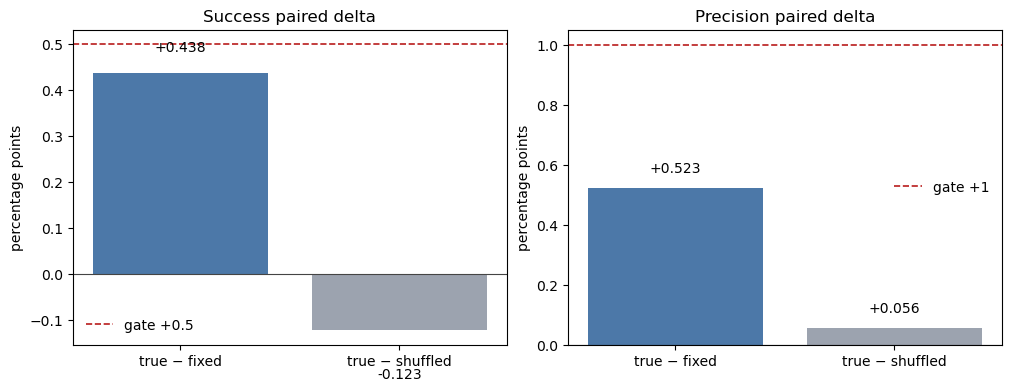

In [6]:
plot_data = {
    "Success": [deltas.loc["true:fixed", "success_left_minus_right"], deltas.loc["true:shuffled", "success_left_minus_right"]],
    "Precision": [deltas.loc["true:fixed", "precision_left_minus_right"], deltas.loc["true:shuffled", "precision_left_minus_right"]],
}
comparisons = ["true − fixed", "true − shuffled"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
for ax, (metric, values), gate in zip(axes, plot_data.items(), [0.5, 1.0]):
    bars = ax.bar(comparisons, values, color=["#4c78a8", "#9ca3af"])
    ax.axhline(gate, color="#b91c1c", linestyle="--", linewidth=1.2, label=f"gate +{gate:g}")
    ax.axhline(0, color="#444", linewidth=0.8)
    ax.set_title(f"{metric} paired delta")
    ax.set_ylabel("percentage points")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, value + (0.04 if value >= 0 else -0.08), f"{value:+.3f}", ha="center", va="bottom" if value >= 0 else "top")
    ax.legend(frameon=False)
plt.show()

### 4. The mean-error gain over fixed time is dominated by one already-failed tracklet


In [7]:
tracklet_deltas = pd.read_csv(root / "analysis/p0c_d1_gap1124_manual_20260721_tracklet_deltas.csv")
for comparison in ["true:fixed", "true:shuffled"]:
    subset = tracklet_deltas.loc[tracklet_deltas.comparison == comparison].copy()
    cols = ["tracklet_key", "success_delta_left_minus_right", "precision_delta_left_minus_right",
            "center_error_gain_left_over_right", "empty_fallback_delta_left_minus_right"]
    print(comparison, "largest absolute center-error contributions")
    display(subset.loc[subset.center_error_gain_left_over_right.abs().nlargest(5).index, cols].round(6))

def metrics_without(tracklet_key, left, right):
    left_frame = frames[left].loc[frames[left].tracklet_key != tracklet_key]
    right_frame = frames[right].loc[frames[right].tracklet_key != tracklet_key]
    ls, rs = tracking_scores(left_frame), tracking_scores(right_frame)
    return {
        "excluded_tracklet": tracklet_key,
        "success_delta": ls["success"] - rs["success"],
        "precision_delta": ls["precision"] - rs["precision"],
        "mean_error_delta": ls["mean_center_error"] - rs["mean_center_error"],
        "fallback_delta": int(left_frame.empty_fallback.sum() - right_frame.empty_fallback.sum()),
        "endpoints": len(left_frame),
    }
loo = pd.DataFrame([
    metrics_without("0cfdfb5bbe8a41268271e24f2edefb9c", "true", "fixed"),
    metrics_without("898c8b3c29d64d80806dd5e5fc6c02d3", "true", "shuffled"),
], index=["true:fixed", "true:shuffled"])
display(loo.round(6))

true:fixed largest absolute center-error contributions


,tracklet_key,success_delta_left_minus_right,precision_delta_left_minus_right,center_error_gain_left_over_right,empty_fallback_delta_left_minus_right
5,0cfdfb5bbe8a41268271e24f2edefb9c,0.000000,0.000000,9.091124,-12
63,bbe3bc5ca1434a2ea802f5ed5062785e,14.615385,0.000000,1.779583,0
50,898c8b3c29d64d80806dd5e5fc6c02d3,0.000000,0.000000,1.178055,0
28,4a8058d0441a46d381995e1af1086039,15.555556,25.555556,0.509076,0
2,06ff24b7f1e8479b934f1b74348028bc,0.000000,0.000000,0.405399,0


true:shuffled largest absolute center-error contributions


,tracklet_key,success_delta_left_minus_right,precision_delta_left_minus_right,center_error_gain_left_over_right,empty_fallback_delta_left_minus_right
141,898c8b3c29d64d80806dd5e5fc6c02d3,-9.166667,0.000000,-4.656198,0
96,0cfdfb5bbe8a41268271e24f2edefb9c,0.000000,0.000000,1.111124,0
133,7328a1bef88b4e84aa2ee0d837effd8d,0.000000,0.000000,-1.085112,0
93,06ff24b7f1e8479b934f1b74348028bc,-5.588235,1.029412,-0.835915,2
154,bbe3bc5ca1434a2ea802f5ed5062785e,-6.153846,-17.115385,-0.531400,0


,excluded_tracklet,success_delta,precision_delta,mean_error_delta,fallback_delta,endpoints
true:fixed,0cfdfb5bbe8a41268271e24f2edefb9c,0.444984,0.531958,-0.039746,0,1236
true:shuffled,898c8b3c29d64d80806dd5e5fc6c02d3,-0.079936,0.055955,-0.001344,2,1251


### 5. Gap and displacement cuts do not show a general physical-time advantage


In [8]:
bin_rows = []
for family in ["by_current_delta_t_real", "by_gt_displacement"]:
    for bin_name, true_values in analysis["runs"]["true"][family].items():
        for control in ["fixed", "shuffled"]:
            control_values = analysis["runs"][control][family][bin_name]
            bin_rows.append({
                "family": family, "bin": bin_name, "control": control,
                "n": true_values["count"],
                "success_delta": true_values["success"] - control_values["success"],
                "precision_delta": true_values["precision"] - control_values["precision"],
                "mean_error_delta": true_values["mean_center_error"] - control_values["mean_center_error"],
            })
bins = pd.DataFrame(bin_rows)
display(bins.loc[(bins.family == "by_current_delta_t_real") & (bins.bin != "missing")].round(6))
display(bins.loc[bins.family == "by_gt_displacement"].round(6))

,family,bin,control,n,success_delta,precision_delta,mean_error_delta
0,by_current_delta_t_real,"[-inf,0.75)",fixed,644,0.496894,0.613354,-0.178794
1,by_current_delta_t_real,"[-inf,0.75)",shuffled,644,-0.077640,0.097050,0.031331
2,by_current_delta_t_real,"[0.75,1.0)",fixed,165,0.181818,0.136364,-0.195867
3,by_current_delta_t_real,"[0.75,1.0)",shuffled,165,-0.333333,0.136364,0.031379
4,by_current_delta_t_real,"[1.0,2.0)",fixed,257,0.622568,0.505837,-0.237390
5,by_current_delta_t_real,"[1.0,2.0)",shuffled,257,-0.194553,-0.262646,0.009924
6,by_current_delta_t_real,"[2.0,inf)",fixed,100,0.400000,1.100000,-0.315696
7,by_current_delta_t_real,"[2.0,inf)",shuffled,100,0.000000,0.525000,-0.016491


,family,bin,control,n,success_delta,precision_delta,mean_error_delta
10,by_gt_displacement,"[-inf,0.5)",fixed,1191,0.461797,0.547859,-0.201713
11,by_gt_displacement,"[-inf,0.5)",shuffled,1191,-0.130143,0.062972,0.023918
12,by_gt_displacement,"[0.5,1.0)",fixed,14,0.000000,0.357143,0.010090
13,by_gt_displacement,"[0.5,1.0)",shuffled,14,0.000000,-0.357143,-0.016606
14,by_gt_displacement,"[1.0,2.0)",fixed,7,0.000000,0.000000,-0.037673
15,by_gt_displacement,"[1.0,2.0)",shuffled,7,0.000000,0.000000,-0.009668
16,by_gt_displacement,"[2.0,4.0)",fixed,17,0.000000,0.000000,0.014170
17,by_gt_displacement,"[2.0,4.0)",shuffled,17,0.000000,0.000000,-0.016598
18,by_gt_displacement,"[4.0,inf)",fixed,28,0.000000,0.000000,0.002925
19,by_gt_displacement,"[4.0,inf)",shuffled,28,0.000000,0.000000,-0.058870


## Takeaways

1. **Data quality is sufficient for an M0-1 diagnostic decision.** Archive integrity, full coverage, exact endpoint identity/order, invariant real-time inputs, time-control semantics, hashes, finite values, and CSV-summary metric equality all pass.
2. **Correct physical-time alignment is not causally supported by this feature-concat A2 checkpoint.** The gain over fixed time is small and below gate; shuffled time matches or beats true on headline metrics.
3. **The largest mean-error improvement is not a tracking recovery.** The outlier tracklet has IoU zero from its first predicted frame in all modes; fixed merely drifts farther and later falls back, so Success does not improve.
4. **There is a localized positive example, not a general mechanism.** A few tracklets improve after a long-gap event, but other tracklets are substantially better under shuffled time and tracklet-bootstrap intervals for Success/Precision include zero.
5. **Stage decision:** mark P0-C-D1 endpoint localization complete and preserve `NO_GO_P0C_A2_TRUE_DT_PROMOTION`. Do not unlock M1 training or M2. Continue M0-2 A/B/C frozen protocols, M0-3 proposal oracle, and M0-4 candidate audit.
